# Linear least squares fit

Solve the tasks below.
For each task, give reasons for your solution by commenting in the notebook.
In conclusion, summarize your findings and contextualize them. What have you learned? Do the results make sense?

Your results will be examined for plagiarism. Please use your own plot styles, articulate your own thoughts, and present your own experimental approaches.

## Tasks

Perform a least squares fit of a parabola of third order

$$ y(x) = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 $$

for the thirteen independent measurments $(x_i, y_i)$ given by $(-1.5, -8.0 \pm 2.5)$, $(-1.25, -2.5 \pm 2.0)$, $(-1.0, -1.5 \pm 1.5)$, $(-0.75, 1.0 \pm 1.0)$, $(-0.5, 4.0 \pm 1.0)$, $(-0.25, 4.0 \pm 0.5)$, $(0.0, 5.5 \pm 0.5)$, $(0.25, 4.5 \pm 0.5)$, $(0.5, 5.5 \pm 0.5)$, $(0.75, 3.0 \pm 1.0)$, $(1.0, 3.0 \pm 1.0)$, $(1.25, 4.5 \pm 1.5)$, $(1.5, 7.0 \pm 2.0)$. 

a) Determine the best fit parameters $\hat \theta_i$ and their covariances using the formula for linear least squares fits.

b) Determine the $\chi_\mathrm{obs}^2$ for the best fit parameter. What is the number of degrees of freedom? Plot the $\chi^2$ distribution and indicate $\chi_\mathrm{obs}^2$ in this plot (e.g. by drawing a line at this value).
What is the $p$-value for this fit?

c) Plot the fitted parabola and the $1\sigma$ error band around it as obtaind from the error propagation formula $\sigma_y^2 = A^\mathrm{T} U A$. What is the predicted value $y$ at $x=1$ and its uncertainty?

d) Compare the fit result and the covariance matrix with the results obtained with iminuit. Do the results agree?

e) Plot the data with a straight-line fit. Determine the $p$-value for this straight-line fit. Is this an acceptable description of the data?

f) How does the $p$-value for a straight-line fit change if the error bars are twice as high in this example? Would you say the fit is describing the data well in this case?


### Hints

1) The following numpy functions might come in very handy
* diagonal matrix from vector v in numpy: *A = np.diagflat(v)*
* matrix from column vectors v0, v1, v2, v3: *A = np.column_stack((v0, v1, v2, v3))*
* multiplication of matrices A and B in numpy: *C = A.dot(B)*
* transposed matrix: *A_T = np.transpose(A)*
* inverse matrix: *A_inv = inv(A)*, this requires *from numpy.linalg import inv*

2) It might be useful to write a function which returns the uncertainty $\sigma_y$ for a numpy array of $x$ values. A function $f$ that only works for a scalar value $x$ can be vectorized (i.e., it works also for numpy arrays) with *numpy.vectorize*.

3) Data points with error bars can be drawn with *plt.errorbar(x, y, yerr=sigma_y)*

4) A band between $y$ values can be drawn with the aid of *matplotlib.pyplot.fill_between*

## Comments on Python's `iminuit`

The KIP service has iminuit version 1.3.8. Please note that the most recent version is $\geq2.0.0$ and that the [documentation](https://iminuit.readthedocs.io/en/stable/) applies to *that* version. Some backward-incompatible changes have been introduced, some of which changed some interfaces. For your tasks that mainly affects the `minuit.Minuit` constructor. The following shows the construction of a `Minuit` object for version 1.3.8 (in case you use the KIP service or a version $<2.0.0$) and $\geq2.0.0$ (in case you use another service implementing a higher version), respectively.
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=1
# likelihood method: errordef=0.5
m = Minuit(func, par1=0.1, par2=0.1, ..., parN=0.1, errordef=1)
```

And this would be the equivalent workflow for versions >2.0.0
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=Minuit.LEAST_SQUARES
# likelihood method: errordef=Minuit.LIKELIHOOD

# add errordef as an attribute of your defined minimisation function which will be checked for when optimised
func.errordef = Minuit.LEAST_SQUARES
m = Minuit(func, par1=0.1 par2=0.1, ..., parN=0.1)
```

Another (potenitally) Jupiter related *feature* is the fact that `m.migrad()`, `m.matrix()`, `m.minos()` etc. can yield a nice summary of the respective procedure. However, in order to show it, either of these methods (and potentially others in case you use them) have to be *the last line of a code cell*. If there is *anything* coming afterwards, the output will not be printed, hence, for anything that follows, it is recommended to start a new code cell.


## Solution

### Finding best fit parameters
a) Determine the best fit parameters $\hat \theta_i$ and their covariances using the formula for linear least squares fits.

We define a function to calculate the sum of the square differences (weighted by the error) between two data sets. Then we define a polynomial function with free coefficients (our model parameters $\hat \theta_i$). Combining these, we get a function which takes the $\hat \theta_i$ as inputs and calculates the sum of the square residuals ($\chi^2$) between the given data set and the current prediction.

This final function is then minimized using `iminuit` and its `Minuit` method, producing a clean summary table of the optimized parameters as well as their errors, given in the form of the Hesse/covariance matrix. Below this the values from the fit are read out manually as a demonstration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
from iminuit import Minuit

In [2]:
# data
x = np.array([-1.5,-1.25, -1., -0.75, -0.5, -0.25, 0., 0.25, 0.5, 0.75, 1.0, 1.25, 1.5])
y = np.array([-8, -2.5, -1.5, 1., 4.0, 4., 5.5, 4.5, 3.5, 3., 3., 4.5, 7.])
sigma_y = np.array([2.5, 2., 1.5, 1, 1, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 1.5, 2.])

In [3]:
# takes two data sets and sums their square differences, weighted by an error
def sum_square_residuals(
        data1: np.ndarray | float,
        data2: np.ndarray | float,
        data1_err: np.ndarray | float) -> float:
    square_residuals = (data1 - data2)**2/data1_err**2
    return np.sum(square_residuals)

# define a polynomial function with string representation and jacobian
class Polynomial:
    def __init__(self, params: list) -> None:
        self.params = params
        self.degree = len(self.params)-1
        self.exponents = range(self.degree+1)
    def eval(self, x):
        result = 0
        for i, theta in enumerate(self.params):
            result += theta * x**i
        return result
    def __str__(self) -> str:
        FIGS = 3
        string = str(round(self.params[0], FIGS))
        for i, param in enumerate(self.params[1:]):
            string += f' + {round(self.params[i+1], FIGS)}*x^{i}'
        return string
    def jacobian(self, x):
        x = np.asarray(x)
        powers = np.arange(self.degree+1)
        return x[:, None] ** powers


def chi_square_for_params(*args):
    cubic = Polynomial([*args])
    data2 = cubic.eval(x)
    return sum_square_residuals(y, data2, sigma_y)

# ===============
# errordef = Minuit.LEAST_SQUARES
# # add errordef as an attribute of your defined minimisation function which will be checked for when optimised
# # chi_square_for_params.errordef = Minuit.LEAST_SQUARES
# ^ ?????
# ===============

m = Minuit(chi_square_for_params, *[1, 1, 1, 1])
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9.765                      │              Nfcn = 88               │
│ EDM = 7.24e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │   4.55    │   0.26    │            │            │         │         │       │
│ 1 │ x1   │   -0.4    │    0.7    │            │            │         │         │       │
│ 2 │ x2   │   -3.0    │    0.5    │            │            │         │         │       │
│ 3 │ x3   │    2.4    │    0.6    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬─────────────────────────────┐
│    │     x0     x1     x2     x3 │
├────┼─────────────────────────────┤
│ x0 │ 0.0686  -0.03  -0.07   0.02 │
│ x1 │  -0.03  0.482   0.01  -0.32 │
│ x2 │  -0.07   0.01  0.244  -0.04 │
│ x3 │   0.02  -0.32  -0.04  0.329 │
└────┴─────────────────────────────┘

In [ ]:
# put a minus or a space in front of a float
def minus_pad(num: float) -> str:
    if num < 0:
        return str(num)
    return ' ' + str(num)

params = list(m.values)
params_error = list(m.errors)

for i, [theta, theta_error] in enumerate(zip(params, params_error)):
    print(f'theta_{i}: {minus_pad(round(theta, 6))} ± {round(theta_error, 6)}')

print()
print(Polynomial(params))

theta_0:  4.548747 ± 0.261846
theta_1: -0.429698 ± 0.694536
theta_2: -2.959048 ± 0.493851
theta_3:  2.408272 ± 0.573842

4.549 + -0.43*x^0 + -2.959*x^1 + 2.408*x^2
[[1 1 1 1]
 [1 2 4 8]]


### $\chi^2$ Analysis
b) Determine the $\chi_\mathrm{obs}^2$ for the best fit parameter. What is the number of degrees of freedom? Plot the $\chi^2$ distribution and indicate $\chi_\mathrm{obs}^2$ in this plot (e.g. by drawing a line at this value).
What is the $p$-value for this fit?

### Plotting the Calculated Curve
c) Plot the fitted parabola and the $1\sigma$ error band around it as obtaind from the error propagation formula $\sigma_y^2 = A^\mathrm{T} U A$. What is the predicted value $y$ at $x=1$ and its uncertainty?

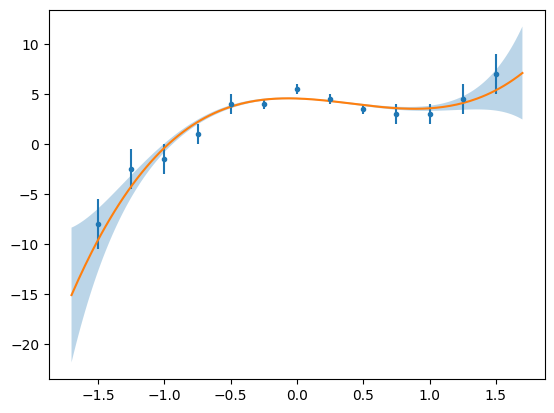

In [5]:
cubic_fit = Polynomial(params)

plt.errorbar(x, y, yerr = sigma_y, linestyle='', marker='.')
grid = np.linspace(-1.7, 1.7, 200)
y_prediction = cubic_fit.eval(grid)
J = cubic_fit.jacobian(grid)
cov = np.array(m.covariance)
sigma = np.diag(J @ cov @ J.T)
lower = y_prediction - sigma
upper = y_prediction + sigma
plt.plot(grid, y_prediction)
plt.fill_between(grid, lower, upper, alpha=0.3);

### Comparing to ```iminuit```
d) Compare the fit result and the covariance matrix with the results obtained with iminuit. Do the results agree?

### Straight Line Fit
e) Plot the data with a straight-line fit. Determine the $p$-value for this straight-line fit. Is this an acceptable description of the data?

### $p$-Value
f) How does the $p$-value for a straight-line fit change if the error bars are twice as high in this example? Would you say the fit is describing the data well in this case?